 ## Reuters dataset
### a set of short newswires and their topics, published
### by Reuters in 1986. It’s a simple, widely used toy dataset for text classification.

In [1]:
from tensorflow.keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

I0000 00:00:1781087883.294662    7103 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781087884.031665    7103 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781087887.085962    7103 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [2]:
len(train_data)

8982

In [3]:
len(test_data)

2246

In [5]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

# Decoding newswires back to text

In [7]:
token_to_text = train_data[10]
word_index = reuters.get_word_index()
reverse_word_index = dict(
[(value, key) for (key, value) in word_index.items()])
# Note that the indices are offset by 3 because 0, 1, and 2 are reserved indices for “padding,” “start of sequence,” and “unknown.
decoded_newswire = " ".join([reverse_word_index.get(i - 3, "?") for i in token_to_text])

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 2us/step


In [8]:
decoded_newswire

'? period ended december 31 shr profit 11 cts vs loss 24 cts net profit 224 271 vs loss 511 349 revs 7 258 688 vs 7 200 349 reuter 3'

### The label associated with an example is an integer between 0 and 45 a topic index

In [10]:
train_labels[10]

np.int64(3)

# Encoding the input data

In [11]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results

In [12]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

### To vectorize the labels, there are two possibilities: you can cast the label list as an inte-
### ger tensor, or you can use one-hot encoding.

In [15]:
# One-hot-encoding
def to_one_hot(labels, dimension=46):
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label] = 1.
    return results

In [16]:
y_train = to_one_hot(train_labels)
y_test = to_one_hot(test_labels)

In [17]:
# built-in-way
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

# Model definition

In [27]:
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt

In [21]:

model = keras.Sequential([
                            layers.Dense(64, activation="relu"),
                            layers.Dense(64, activation="relu"),
                            layers.Dense(46, activation="softmax")
                        ])

### The best loss function to use in this case is categorical_crossentropy. It measures the distance between two probability distributions

In [23]:
model.compile(optimizer="rmsprop",loss="categorical_crossentropy",metrics=["accuracy"])

# Setting aside a validation set

In [24]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [25]:
# Now, let’s train the model for 20 epochs
history = model.fit(partial_x_train,partial_y_train,epochs=20,batch_size=512,validation_data=(x_val, y_val))

W0000 00:00:1781089227.347590    7103 cpu_allocator_impl.cc:82] Allocation of 319280000 exceeds 10% of free system memory.


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3731 - loss: 3.2592

W0000 00:00:1781089230.237855    7103 cpu_allocator_impl.cc:82] Allocation of 40000000 exceeds 10% of free system memory.


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.4827 - loss: 2.7360 - val_accuracy: 0.6250 - val_loss: 1.8264
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6832 - loss: 1.5575 - val_accuracy: 0.6980 - val_loss: 1.4060
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7430 - loss: 1.2107 - val_accuracy: 0.7270 - val_loss: 1.2343
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7838 - loss: 1.0003 - val_accuracy: 0.7590 - val_loss: 1.1316
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8163 - loss: 0.8408 - val_accuracy: 0.7760 - val_loss: 1.0546
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8473 - loss: 0.7097 - val_accuracy: 0.7760 - val_loss: 1.0143
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8685 - loss: 0.5982 - val_accuracy: 0.7850 - val_loss: 0.9694
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8882 - loss: 0.5078 - val_accuracy: 0.8050 - val_loss: 0.

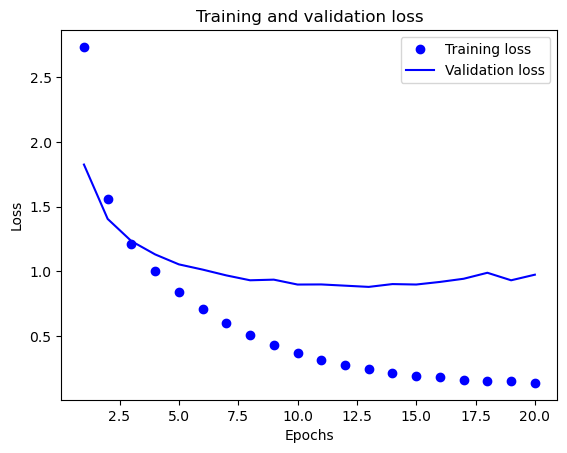

In [28]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

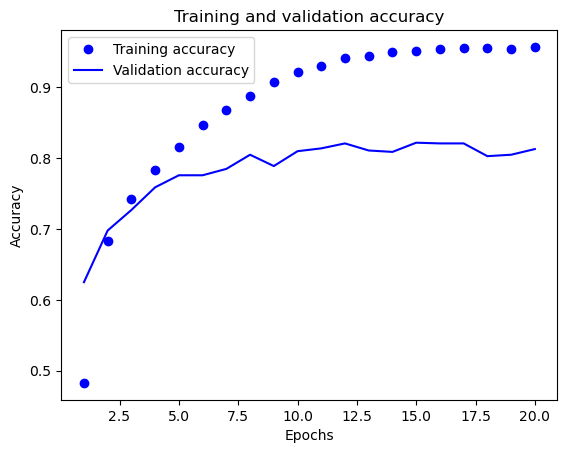

In [29]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# The model begins to overfit after nine epochs.

In [30]:
model = keras.Sequential([
                            layers.Dense(64, activation="relu"),
                            layers.Dense(64, activation="relu"),
                            layers.Dense(46, activation="softmax")
                        ])



model.compile(optimizer="rmsprop",loss="categorical_crossentropy",metrics=["accuracy"])
model.fit(x_train,y_train,epochs=9,batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/9


W0000 00:00:1781089401.653469    7103 cpu_allocator_impl.cc:82] Allocation of 359280000 exceeds 10% of free system memory.


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5114 - loss: 2.5861
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6992 - loss: 1.4096
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7636 - loss: 1.0917
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8081 - loss: 0.8938
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8412 - loss: 0.7403
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8656 - loss: 0.6159
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8906 - loss: 0.5138
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9075 - loss: 0.4328
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9234 - loss: 0.3651
 1/71 ━━━━━━━━━━━━━━━━━━━━ 12s 174ms/step - accuracy: 0.8750 - loss: 0.6092

W0000 00:00:1781089410.927852    7103 cpu_allocator_impl.cc:82] Allocation of 89840000 exceeds 10% of free system memory.


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7898 - loss: 0.9288


In [31]:
results

[0.9287697672843933, 0.7898486256599426]